# Thermostats 

Here, we are comparing different thermostats to each other. We start with the most widely used one, the Nose-Hoover thermostat. 
Many open source codes have multiple thermostats implemented: 

- LAMMPS: https://docs.lammps.org/Howto_thermostat.html
- GROMACS: https://manual.gromacs.org/5.1.1/user-guide/mdp-options.html#temperature-coupling
- HOOMD-blue: https://hoomd-blue.readthedocs.io/en/stable/hoomd/md/methods/module-thermostats.html

Let's look at how Nose-Hoover thermostat brings a system from $\sim 0kT$ to the target temperature, in this case $1.5kT$:

In [2]:
import numpy as np 
import matplotlib 
import matplotlib.pyplot as plt 
import gsd,gsd.hoomd 
import scipy.stats as stats

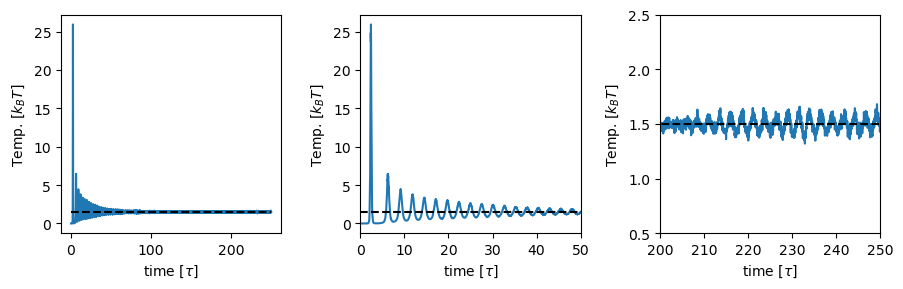

In [4]:
timestep = 0.005 
set_temp = 1.5 

data = np.genfromtxt('run_liquid_MTTK_0.64_1.50.log') 

fig, ax = plt.subplots(1,3,figsize=(9,3))
for a in ax:
    a.plot(data[:,0]*timestep,data[:,1])
    a.plot([0,250],[set_temp,set_temp],c='black',linestyle='dashed')
    a.set_xlabel(r'time $[\tau]$')
    a.set_ylabel(r'Temp. $[k_BT]$')
    
ax[1].set_xlim([0,50])
ax[2].set_xlim([200,250])
ax[2].set_ylim([0.5,2.5])

fig.tight_layout()
plt.show()

Oscillations are clearly visible. This is a known effect. It depends on the coupling constant $Q=gkT\tau^2$, where $\tau$ here is the coupling time, NOT the unit of time (also called $\tau$). We can look at the "equilibrated" temperature distribution, also see [Phys. Rev. E 52, 2338 1995](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.52.2338): 

Mean: exp: 1.50 measured: 1.50
Variance: exp: 0.0030 measured: 0.0026


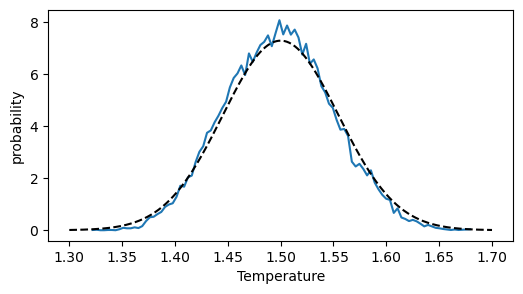

In [5]:

fig, ax = plt.subplots(1,1,figsize=(6,3))
counts, b = np.histogram(data[20000:,1], bins=100,density=True) 
bincenters = (b[1:] + b[:-1])/2
ax.plot(bincenters,counts)

T = np.linspace(1.3,1.7,num=1000)
exp_average = 1.5 
calc_average = np.average(data[20000:,1])
print("Mean: exp: %1.2f measured: %1.2f"%(exp_average,calc_average))

exp_variance = 2/3*exp_average**2/500 
calc_variance = np.var(data[20000:,1])
print("Variance: exp: %1.4f measured: %1.4f"%(exp_variance,calc_variance))


ax.plot(T, stats.norm.pdf(T, exp_average, np.sqrt(exp_variance)),c='black',linestyle='dashed')
ax.set_xlabel('Temperature') 
ax.set_ylabel('probability')

plt.show()

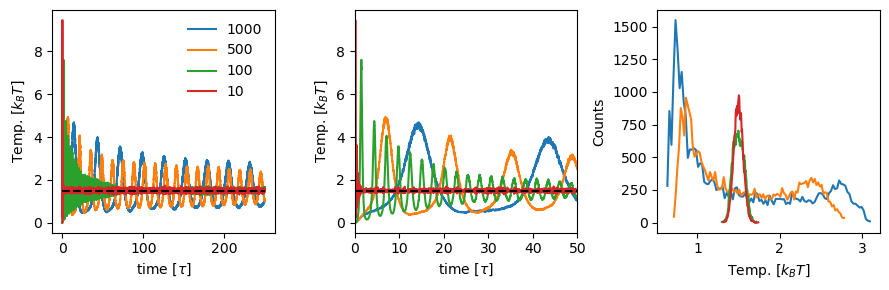

In [5]:
timestep = 0.005 
set_temp = 1.5 

fig, ax = plt.subplots(1,3,figsize=(9,3))

for coupling in [1000,500,100,10]:
    data = np.genfromtxt('run_liquid_MTTK_%f_0.64_1.50.log'%coupling) 
    ax[0].plot(data[:,0]*timestep,data[:,1],label='%s'%coupling)
    ax[1].plot(data[:,0]*timestep,data[:,1])
    counts, b = np.histogram(data[20000:,1], bins=100) 
    bincenters = (b[1:] + b[:-1])/2
    ax[2].plot(bincenters,counts)
    
ax[0].set_xlabel(r'time $[\tau]$')
ax[0].set_ylabel(r'Temp. $[k_BT]$')
ax[1].set_xlabel(r'time $[\tau]$')
ax[1].set_ylabel(r'Temp. $[k_BT]$')

ax[2].set_ylabel(r'Counts')
ax[2].set_xlabel(r'Temp. $[k_BT]$')

ax[0].legend(frameon=False)
ax[1].set_xlim([0,50])
ax[0].plot([0,250],[set_temp,set_temp],c='black',linestyle='dashed')
ax[1].plot([0,50],[set_temp,set_temp],c='black',linestyle='dashed')

fig.tight_layout()
plt.show()

# Comparison between Thermostats 

Now let's compare Nose-Hoover ('MTTK', see papers: [J. Chem. Phys. 101, 4177–4189 (1994)](https://pubs.aip.org/aip/jcp/article-abstract/101/5/4177/165484/Constant-pressure-molecular-dynamics-algorithms?redirectedFrom=fulltext ) and [J. Chem. Phys. 104, 2028–2035 (1996)](https://pubs.aip.org/aip/jcp/article-abstract/104/5/2028/478535/Adiabatic-path-integral-molecular-dynamics-methods?redirectedFrom=fulltext) )  with Berendsen, Langevin, and Bussi thermostats: 

50002
50002
50002
50002


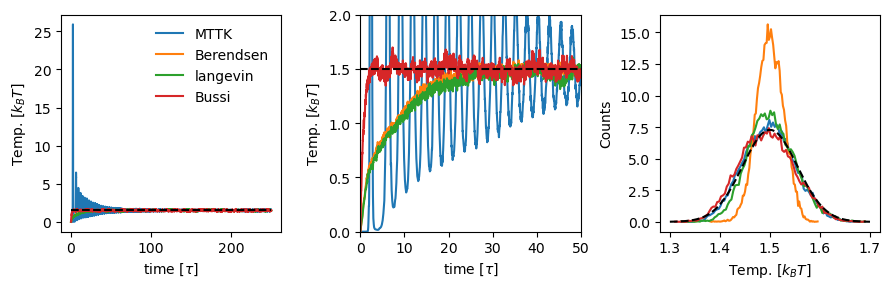

In [9]:
timestep = 0.005 
set_temp = 1.5 

fig, ax = plt.subplots(1,3,figsize=(9,3))

for thermostats in ['MTTK',"Berendsen",'langevin','Bussi']:
    data = np.genfromtxt('run_liquid_%s_0.64_1.50.log'%thermostats) 
    ax[0].plot(data[:,0]*timestep,data[:,1],label='%s'%thermostats)
    ax[1].plot(data[:,0]*timestep,data[:,1])
    print(len(data))
    counts, b = np.histogram(data[20000:,1], bins=100,density=True) 
    bincenters = (b[1:] + b[:-1])/2
    ax[2].plot(bincenters,counts)

    
ax[0].set_xlabel(r'time $[\tau]$')
ax[0].set_ylabel(r'Temp. $[k_BT]$')
ax[1].set_xlabel(r'time $[\tau]$')
ax[1].set_ylabel(r'Temp. $[k_BT]$')

ax[2].set_ylabel(r'Counts')
ax[2].set_xlabel(r'Temp. $[k_BT]$')

ax[0].legend(frameon=False)
ax[1].set_xlim([0,50])
ax[1].set_ylim([0,2])
ax[0].plot([0,250],[set_temp,set_temp],c='black',linestyle='dashed')
ax[1].plot([0,50],[set_temp,set_temp],c='black',linestyle='dashed')

ax[2].plot(T, stats.norm.pdf(T, exp_average, np.sqrt(exp_variance)),c='black',linestyle='dashed')

fig.tight_layout()
plt.show()

# Langevin Coupling Constant 

We can also vary the coupling constant for other thermostats, e.g. the Langevin $\gamma$ parameter: 

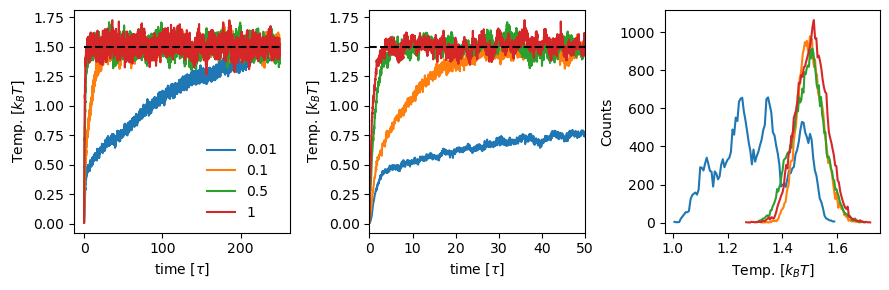

In [8]:
timestep = 0.005 
set_temp = 1.5 

fig, ax = plt.subplots(1,3,figsize=(9,3))

for coupling in [0.01,0.1,0.5,1]:
    data = np.genfromtxt('run_liquid_langevin_%f_0.64_1.50.log'%coupling) 
    ax[0].plot(data[:,0]*timestep,data[:,1],label='%s'%coupling)
    ax[1].plot(data[:,0]*timestep,data[:,1])
    counts, b = np.histogram(data[20000:,1], bins=100) 
    bincenters = (b[1:] + b[:-1])/2
    ax[2].plot(bincenters,counts)

    
ax[0].set_xlabel(r'time $[\tau]$')
ax[0].set_ylabel(r'Temp. $[k_BT]$')
ax[1].set_xlabel(r'time $[\tau]$')
ax[1].set_ylabel(r'Temp. $[k_BT]$')

ax[2].set_ylabel(r'Counts')
ax[2].set_xlabel(r'Temp. $[k_BT]$')

ax[0].legend(frameon=False)
ax[1].set_xlim([0,50])
ax[0].plot([0,250],[set_temp,set_temp],c='black',linestyle='dashed')
ax[1].plot([0,50],[set_temp,set_temp],c='black',linestyle='dashed')

fig.tight_layout()
plt.show()

# Velocity Distributions 

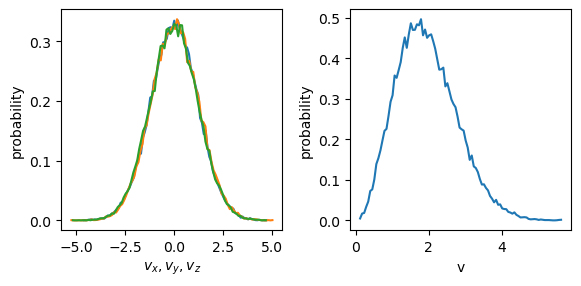

In [6]:
trajectory = gsd.hoomd.open('run_liquid_langevin_0.100000_0.64_1.50.gsd')

v_x = [] 
v_y = [] 
v_z = []
v = [] 
for frame in trajectory[-100:]:
    v_x.append(frame.particles.velocity[:,0])
    v_y.append(frame.particles.velocity[:,1])
    v_z.append(frame.particles.velocity[:,2])
    v.append(np.linalg.norm(frame.particles.velocity,axis=1))

fig, ax = plt.subplots(1,2,figsize=(6,3))

counts, b = np.histogram(v_x, bins=100,density=True) 
bincenters = (b[1:] + b[:-1])/2
ax[0].plot(bincenters,counts)
counts, b = np.histogram(v_y, bins=100,density=True) 
bincenters = (b[1:] + b[:-1])/2
ax[0].plot(bincenters,counts)
counts, b = np.histogram(v_z, bins=100,density=True) 
bincenters = (b[1:] + b[:-1])/2
ax[0].plot(bincenters,counts)

counts, b = np.histogram(v, bins=100,density=True) 
bincenters = (b[1:] + b[:-1])/2
ax[1].plot(bincenters,counts)

ax[0].set_xlabel(r'$v_x,v_y,v_z$')
ax[0].set_ylabel('probability') 

ax[1].set_xlabel('v')
ax[1].set_ylabel('probability')

fig.tight_layout()
plt.show()

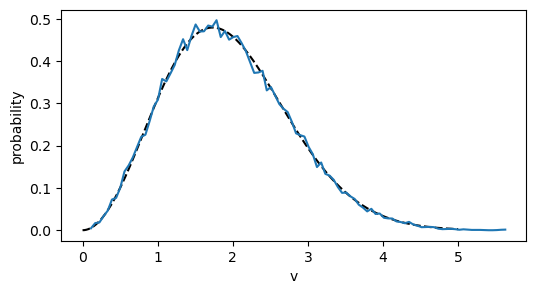

In [27]:
# Maxwell-Boltzmann distribution function
def maxwell_boltzmann(v, k_BT, m):
    return 4 * np.pi * (m / (2 * np.pi * k_BT))**(3/2) * v**2 * np.exp(-m * v**2 / (2 * k_BT))

fig, ax = plt.subplots(1,1,figsize=(6,3))

v = np.linspace(0,5,num=1000)
mb_dist = maxwell_boltzmann(v, 1.5, 1.0)
ax.plot(v,mb_dist, label='MB distribution',color='black',linestyle='dashed')
ax.plot(bincenters,counts,label='langevin $\gamma=0.1$')

ax.set_xlabel('v')
ax.set_ylabel('probability')

plt.show()

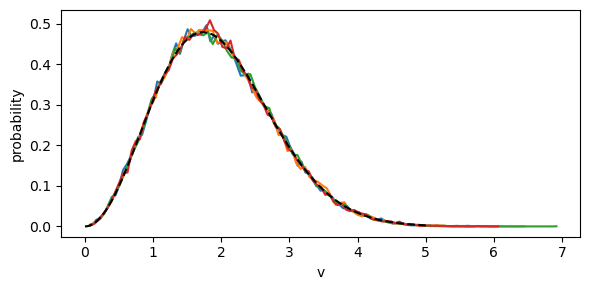

In [30]:

fig, ax = plt.subplots(1,1,figsize=(6,3))

trajectories = ['run_liquid_langevin_0.100000_0.64_1.50.gsd',
                'run_liquid_MTTK_100.000000_0.64_1.50.gsd',
                'run_liquid_Berendsen_0.64_1.50.gsd',
                'run_liquid_Bussi_0.64_1.50.gsd'
               ]

for files in trajectories:
    trajectory = gsd.hoomd.open(files)

    v = [] 
    for frame in trajectory[-100:]:
        v.append(np.linalg.norm(frame.particles.velocity,axis=1))
    
    counts, b = np.histogram(v, bins=100,density=True) 
    bincenters = (b[1:] + b[:-1])/2
    ax.plot(bincenters,counts)

v = np.linspace(0,5,num=1000)
mb_dist = maxwell_boltzmann(v, 1.5, 1.0)
ax.plot(v,mb_dist, label='MB distribution',color='black',linestyle='dashed')
ax.set_xlabel('v')
ax.set_ylabel('probability')

fig.tight_layout()
plt.show()

It is recommended to check:
- Average temperature $<T>$
- Variance of temperature, expectation is $<(\delta T)^2>_0=\frac{2}{d}\frac{<T>^2}{N}$ for a canonical ensenble
- Temperature histogram - should be a Gaussian distribution with $<T>$ average and  $<(\delta T)^2>_0$ variance
- velocity distributions, should follow Maxwell Boltzman distribution, each individual velocity component $v_i$ should be a Gaussian with average 0. 

Beware: 
- Not all thermostats conserve linear and/or angular momentum
- Not all thermostats reproduce the canonical distribution
- Some thermostats are "global" ( control the overall temperature), others are "local" (control individual particle temperatures)
- Not all thermostats are "deterministic" 